<a href="https://colab.research.google.com/github/JenyaSW19/House-Price-Prediction-ML/blob/main/ML_Project_House_Prices_Group7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Advanced House Price Prediction:

Members:  
 - Bahodirov Abdusattor
 - Kim Evgeniy
 - Erkinov Fazliddin
 - Toshpo'latov Abdulhamid

Section 1: Data Preprocessing

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
# Загрузка и очистка
df = pd.read_csv('/content/drive/MyDrive/USA_Housing.csv')
df = df.drop('Address', axis=1)

# Разделение на X и y
y = df['Price']
X = df.drop('Price', axis=1)

# Нормализация ПРИЗНАКОВ (X)
# Мы называем переменную X_normalized, чтобы потом её использовать
X_normalized = (X - X.min()) / (X.max() - X.min())

# Вывод первых строк для проверки
print(X_normalized.head())

# Преобразование в NumPy для твоей секции (Section 2)
X_train = X_normalized.to_numpy()
y_train = y.to_numpy()

print("The data has been successfully prepared!")

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0          0.686822             0.441986                   0.501502   
1          0.683521             0.488538                   0.464501   
2          0.483737             0.468609                   0.701350   
3          0.506630             0.660956                   0.312430   
4          0.469223             0.348556                   0.611851   

   Avg. Area Number of Bedrooms  Area Population  
0                      0.464444         0.329942  
1                      0.242222         0.575968  
2                      0.695556         0.528582  
3                      0.280000         0.491549  
4                      0.495556         0.376988  
The data has been successfully prepared!


Section 2 Mathematical Implementation

In [16]:
import numpy as np

# 1.Function for training the model
def train_model(X, y, learning_rate=0.01, iterations=1000):
    m, n = X.shape
    w = np.zeros(n) # Let's initialize the weights with zeros
    b = 0           # Let's initialize the offset
    cost_history = [] # We'll record the error here
    for i in range(iterations):
        # Prediction
        y_pred = np.dot(X, w) + b

        # Let's calculate the error (MSE)
        error = y_pred - y
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)

        # Calculating gradients
        dw = (1/m) * np.dot(X.T, error)
        db = (1/m) * np.sum(error)

        # Update the parameters (gradient descent step size)
        w = w - learning_rate * dw
        b = b - learning_rate * db

        if i % 100 == 0:
            print(f"Итерация {i}: Ошибка = {cost}")

    return w, b, cost_history

# 2. LET'S START THE TRAINING
print("Let's start training the model...")
weights, bias, history = train_model(X_train, y_train, learning_rate=0.1, iterations=2000)

print("\nTraining completed!")
print(f"Final weights (weights): {weights}")
print(f"Final displacement (bias): {bias}")

Let's start training the model...
Итерация 0: Ошибка = 821335072437.9965
Итерация 100: Ошибка = 33783389744.06985
Итерация 200: Ошибка = 29234406498.991745
Итерация 300: Ошибка = 25555691332.702015
Итерация 400: Ошибка = 22484980759.56138
Итерация 500: Ошибка = 19894456575.657482
Итерация 600: Ошибка = 17700236294.27639
Итерация 700: Ошибка = 15838084112.231382
Итерация 800: Ошибка = 14255813154.41905
Итерация 900: Ошибка = 12910121850.730963
Итерация 1000: Ошибка = 11764778455.634504
Итерация 1100: Ошибка = 10789337905.093967
Итерация 1200: Ошибка = 9958146893.521774
Итерация 1300: Ошибка = 9249544044.977583
Итерация 1400: Ошибка = 8645206963.953503
Итерация 1500: Ошибка = 8129614782.188369
Итерация 1600: Ошибка = 7689603281.836469
Итерация 1700: Ошибка = 7313995015.496526
Итерация 1800: Ошибка = 6993290635.193484
Итерация 1900: Ошибка = 6719410477.655632

Training completed!
Final weights (weights): [1621520.55270671 1005073.94839785  703579.5937044    38693.78943072
  911797.8974457

Section 3 Model Training & Evaluation

The root mean square error (RMSE) of your model: 112890.70704540978
The coefficient of determination (R²) of your model: 0.8964150404687252


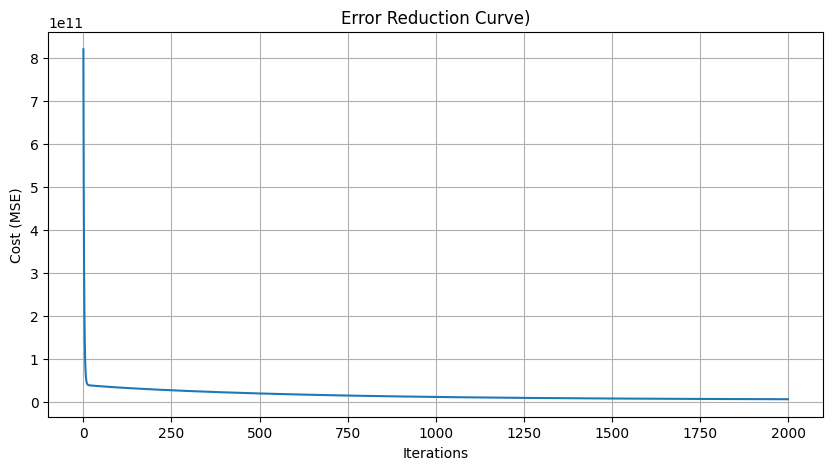

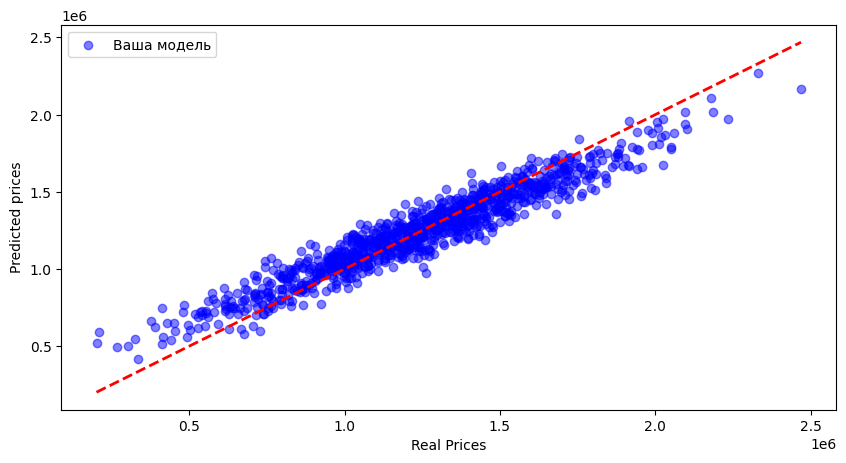

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt

# 1. We split the data into training and test sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 2. We train a standard Sklearn model for comparison
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_split, y_train_split)
y_pred_sklearn = sklearn_model.predict(X_test_split)

# 3. Let's make a prediction using your model (using Zhenya's weights)
y_pred_your_model = np.dot(X_test_split, weights) + bias

# 4. Metrics (Comparison)
print("The root mean square error (RMSE) of your model:", np.sqrt(metrics.mean_squared_error(y_test_split, y_pred_your_model)))
print("The coefficient of determination (R²) of your model:", metrics.r2_score(y_test_split, y_pred_your_model))

# 5. Study Schedule (Based on Zhenya's Mistakes)
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title('Error Reduction Curve)')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.grid(True)
plt.show()

# 6. Chart: Reality vs. Prediction
plt.figure(figsize=(10, 5))
plt.scatter(y_test_split, y_pred_your_model, color='blue', alpha=0.5, label='Ваша модель')
plt.plot([y_test_split.min(), y_test_split.max()], [y_test_split.min(), y_test_split.max()], 'r--', lw=2)
plt.xlabel('Real Prices')
plt.ylabel('Predicted prices')
plt.legend()
plt.show()

Section 4 Comparison & Final Results

In [18]:
import numpy as np
from sklearn import metrics

# Let's calculate the metrics using the variables from Section 3
r2_final = metrics.r2_score(y_test_split, y_pred_your_model)
rmse_final = np.sqrt(metrics.mean_squared_error(y_test_split, y_pred_your_model))

# Let's display the final result
print("--- FINAL RESULTS ---")
print(f"Final R2 Score: {r2_final:.4f}")
print(f"Final RMSE: ${rmse_final:,.2f}")

--- FINAL RESULTS ---
Final R2 Score: 0.8964
Final RMSE: $112,890.71
